# ✈️ Session 1 — Predictive Aircraft Maintenance
## ALICE Club · Applied AI Workshop · UTM Faculty of AI · June 2026

**Student version** — read the explanation in each section, then complete the `# TODO` cells.

---

## 1 · Context

### The problem
Airlines cannot afford an unexpected engine failure.
The goal: predict how many flight cycles remain before an engine needs maintenance.
This is called **RUL — Remaining Useful Life**.

### NASA C-MAPSS
No airline lets an engine actually run to failure — too dangerous.
NASA built **C-MAPSS** *(Commercial Modular Aero-Propulsion System Simulation)*,
a turbofan simulator producing ~90,000 lbs of thrust (≈ 30 cars, Boeing 777 class).

**The 4 sub-datasets:**

| Dataset | Train engines | Test engines | Conditions | Fault modes |
|---------|:---:|:---:|:---:|:---:|
| **FD001** ← we use this one | 100 | 100 | 1 (sea level) | 1 (HPC) |
| FD002 | 260 | 259 | 6 | 1 |
| FD003 | 100 | 100 | 1 | 2 |
| FD004 | 248 | 249 | 6 | 2 |

### Files and columns
```
col 0     : unit_number      — engine ID (1 to 100)
col 1     : time_in_cycles   — current flight cycle
col 2–4   : op_setting_1/2/3 — operating conditions
col 5–25  : sensor_01 to sensor_21 — 21 physical sensor readings
```
- `train_FD001.txt` → full run-to-failure trajectories
- `test_FD001.txt`  → trajectories cut before failure
- `RUL_FD001.txt`   → actual RUL for each test engine

## ⚠️ Rules — never break these

| ❌ Never | ✅ Instead | Why |
|---|---|---|
| `unit_number` as a feature | Drop it | It's an ID, not a physical signal |
| `time_in_cycles` as a feature | Drop it | The model must generalise to unseen engines |
| `train_test_split` on rows | Split by `unit_number` | Row split → data leakage |
| Unbounded RUL | Clip at 125 | Stabilises training |
| Keep constant sensors | Drop them | They add noise, not signal |

## 2 · Setup
> Provided cell — run it as-is, do not modify.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, os

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})

In [40]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Adjust this path if your Drive folder has a different name
DATA_DIR = '/content/drive/MyDrive/ml/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
# Column names for the 26 raw columns (no header in the .txt files)
COL_NAMES = (
    ['unit_number', 'time_in_cycles',
     'op_setting_1', 'op_setting_2', 'op_setting_3']
    + [f'sensor_{i:02d}' for i in range(1, 22)]
)

def load_cmapss(filepath):
    """Load a C-MAPSS file. sep=r'\s+' handles multiple spaces."""
    df = pd.read_csv(filepath, sep=r'\s+', header=None, engine='python')
    df.dropna(axis=1, how='all', inplace=True)  # remove 2 empty trailing columns
    df.columns = COL_NAMES
    return df

---
## ✏️ Exercise 1 / 8 — Load the data

To load the `.txt` files, use the `load_cmapss()` function defined above.
For the RUL file, use `pd.read_csv()` with `header=None` and `names=['RUL']`.

---

In [45]:
# TODO: load train_FD001.txt into train_df
train_df = load_cmapss(DATA_DIR + 'train_FD001.txt')


# TODO: load test_FD001.txt into test_df
test_df = load_cmapss(DATA_DIR  + 'test_FD001.txt')


# TODO: load RUL_FD001.txt into rul_df
rul_df =pd.read_csv(DATA_DIR + 'RUL_FD001.txt',header=None,names=['RUL'])


# Verification — do not modify
print(f"Train: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")
print(f"Test:  {test_df.shape[0]:,} rows × {test_df.shape[1]} columns")
print(f"RUL:   {rul_df.shape[0]} test engines")

Train: 20,631 rows × 26 columns
Test:  13,096 rows × 26 columns
RUL:   100 test engines


In [48]:
import os

print(f"Listing contents of: {DATA_DIR}")

# List contents of DATA_DIR
if os.path.exists(DATA_DIR):
    print(os.listdir(DATA_DIR))
    # If 'FD001' is expected to be a subdirectory, list its contents too
    fd001_path = os.path.join(DATA_DIR, '')
    if os.path.exists(fd001_path):
        print(f"\nListing contents of: {fd001_path}")
        print(os.listdir(fd001_path))
    else:
        print(f"\n'FD001' directory not found at: {fd001_path}")
else:
    print(f"The base DATA_DIR was not found: {DATA_DIR}")


Listing contents of: /content/drive/MyDrive/ml/
['RUL_FD002.txt', ' readme.txt', ' RUL_FD004.txt', 'test_FD001.txt', ' RUL_FD003.txt', 'test_FD003.txt', 'test_FD004.txt', 'test_FD002.txt', 'RUL_FD001.txt', ' train_FD003.txt', 'train_FD001.txt', 'train_FD004.txt', 'train_FD002.txt', '.ipynb_checkpoints']

Listing contents of: /content/drive/MyDrive/ml/
['RUL_FD002.txt', ' readme.txt', ' RUL_FD004.txt', 'test_FD001.txt', ' RUL_FD003.txt', 'test_FD003.txt', 'test_FD004.txt', 'test_FD002.txt', 'RUL_FD001.txt', ' train_FD003.txt', 'train_FD001.txt', 'train_FD004.txt', 'train_FD002.txt', '.ipynb_checkpoints']


---
## ✏️ Exercise 2 / 8 — First look at the data

Two essential functions to start every dataset exploration:
- **`.shape`** → returns `(number of rows, number of columns)`
- **`.head(n)`** → displays the first `n` rows (5 by default)
- **`.tail(n)`** → displays the last `n` rows

---

In [49]:
# TODO: print the dimensions of train_df
print(train_df.shape)



(20631, 26)


In [50]:
# TODO: display the first 5 rows of train_df

print(train_df.head(5))


   unit_number  time_in_cycles  op_setting_1  op_setting_2  op_setting_3  \
0            1               1       -0.0007       -0.0004         100.0   
1            1               2        0.0019       -0.0003         100.0   
2            1               3       -0.0043        0.0003         100.0   
3            1               4        0.0007        0.0000         100.0   
4            1               5       -0.0019       -0.0002         100.0   

   sensor_01  sensor_02  sensor_03  sensor_04  sensor_05  ...  sensor_12  \
0     518.67     641.82    1589.70    1400.60      14.62  ...     521.66   
1     518.67     642.15    1591.82    1403.14      14.62  ...     522.28   
2     518.67     642.35    1587.99    1404.20      14.62  ...     522.42   
3     518.67     642.35    1582.79    1401.87      14.62  ...     522.86   
4     518.67     642.37    1582.85    1406.22      14.62  ...     522.19   

   sensor_13  sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  \
0    2388.02   

In [51]:
# TODO: display the last 3 rows of train_df

print(train_df.tail(5))


       unit_number  time_in_cycles  op_setting_1  op_setting_2  op_setting_3  \
20626          100             196       -0.0004       -0.0003         100.0   
20627          100             197       -0.0016       -0.0005         100.0   
20628          100             198        0.0004        0.0000         100.0   
20629          100             199       -0.0011        0.0003         100.0   
20630          100             200       -0.0032       -0.0005         100.0   

       sensor_01  sensor_02  sensor_03  sensor_04  sensor_05  ...  sensor_12  \
20626     518.67     643.49    1597.98    1428.63      14.62  ...     519.49   
20627     518.67     643.54    1604.50    1433.58      14.62  ...     519.68   
20628     518.67     643.42    1602.46    1428.18      14.62  ...     520.01   
20629     518.67     643.23    1605.26    1426.53      14.62  ...     519.67   
20630     518.67     643.85    1600.38    1432.14      14.62  ...     519.30   

       sensor_13  sensor_14  sensor_15

---
## ✏️ Exercise 3 / 8 — Data types and missing values

- **`.info()`** → shows each column's dtype and non-null count.
  If "Non-Null Count" < total rows → there are NaNs!
- **`.isnull().sum()`** → counts missing values column by column.
  You cannot train a model with NaN values.

---

In [52]:
# TODO: display info for train_df (dtypes, non-null count, memory)

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     20631 non-null  int64  
 1   time_in_cycles  20631 non-null  int64  
 2   op_setting_1    20631 non-null  float64
 3   op_setting_2    20631 non-null  float64
 4   op_setting_3    20631 non-null  float64
 5   sensor_01       20631 non-null  float64
 6   sensor_02       20631 non-null  float64
 7   sensor_03       20631 non-null  float64
 8   sensor_04       20631 non-null  float64
 9   sensor_05       20631 non-null  float64
 10  sensor_06       20631 non-null  float64
 11  sensor_07       20631 non-null  float64
 12  sensor_08       20631 non-null  float64
 13  sensor_09       20631 non-null  float64
 14  sensor_10       20631 non-null  float64
 15  sensor_11       20631 non-null  float64
 16  sensor_12       20631 non-null  float64
 17  sensor_13       20631 non-null 

In [53]:
# TODO: count and display missing values in train_df

train_df.isnull().sum()


,0
unit_number,0
time_in_cycles,0
op_setting_1,0
op_setting_2,0
op_setting_3,0
sensor_01,0
sensor_02,0
sensor_03,0
sensor_04,0
sensor_05,0


---
## ✏️ Exercise 4 / 8 — Descriptive statistics

- **`.describe()`** → gives count, mean, std, min, 25%, 50%, 75%, max for each numeric column.
  Use `.round(2)` to round to 2 decimal places.
- Check the std (`std`) of sensor columns: if `std ≈ 0`, the column is constant → useless.
- To filter only sensor columns, use a list comprehension:
  `[c for c in train_df.columns if c.startswith('sensor_')]`

---

In [54]:
# TODO: display descriptive statistics for train_df (rounded to 2 decimals)

train_df.describe().round(2)


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00,20631.00,20631.00,20631.00,...,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00
mean,51.51,108.81,-0.00,0.0,100.0,518.67,642.68,1590.52,1408.93,14.62,...,521.41,2388.10,8143.75,8.44,0.03,393.21,2388.0,100.0,38.82,23.29
std,29.23,68.88,0.00,0.0,0.0,0.00,0.50,6.13,9.00,0.00,...,0.74,0.07,19.08,0.04,0.00,1.55,0.0,0.0,0.18,0.11
min,1.00,1.00,-0.01,-0.0,100.0,518.67,641.21,1571.04,1382.25,14.62,...,518.69,2387.88,8099.94,8.32,0.03,388.00,2388.0,100.0,38.14,22.89
25%,26.00,52.00,-0.00,-0.0,100.0,518.67,642.33,1586.26,1402.36,14.62,...,520.96,2388.04,8133.24,8.41,0.03,392.00,2388.0,100.0,38.70,23.22
50%,52.00,104.00,0.00,0.0,100.0,518.67,642.64,1590.10,1408.04,14.62,...,521.48,2388.09,8140.54,8.44,0.03,393.00,2388.0,100.0,38.83,23.30
75%,77.00,156.00,0.00,0.0,100.0,518.67,643.00,1594.38,1414.55,14.62,...,521.95,2388.14,8148.31,8.47,0.03,394.00,2388.0,100.0,38.95,23.37
max,100.00,362.00,0.01,0.0,100.0,518.67,644.53,1616.91,1441.49,14.62,...,523.38,2388.56,8293.72,8.58,0.03,400.00,2388.0,100.0,39.43,23.62


In [55]:
# TODO: create sensor_cols = list of columns starting with 'sensor_'
sensor_cols =[c for c in train_df.columns if c.startswith('sensor_')]
std_raw = train_df[sensor_cols].std().sort_values()

print('Raw sensor std dev (sorted):')
for col,val in std_raw.items():
  note ="<- very low" if val<1.5 else ""
  print(f"  {col}: {val:.4f}{note}")


# TODO: compute the std dev of each sensor and sort from lowest to highest



# Display — do not modify


Raw sensor std dev (sorted):
  sensor_19: 0.0000<- very low
  sensor_18: 0.0000<- very low
  sensor_16: 0.0000<- very low
  sensor_10: 0.0000<- very low
  sensor_05: 0.0000<- very low
  sensor_01: 0.0000<- very low
  sensor_06: 0.0014<- very low
  sensor_15: 0.0375<- very low
  sensor_08: 0.0710<- very low
  sensor_13: 0.0719<- very low
  sensor_21: 0.1083<- very low
  sensor_20: 0.1807<- very low
  sensor_11: 0.2671<- very low
  sensor_02: 0.5001<- very low
  sensor_12: 0.7376<- very low
  sensor_07: 0.8851<- very low
  sensor_17: 1.5488
  sensor_03: 6.1311
  sensor_04: 9.0006
  sensor_14: 19.0762
  sensor_09: 22.0829


---
## ✏️ Exercise 5 / 8 — Engine lifespan distribution

To find each engine's lifespan:
- **`.groupby('unit_number')`** → group rows by engine
- **`['time_in_cycles'].max()`** → take the maximum cycle of each engine (= last cycle before failure)
- **`.reset_index()`** → reset the index after the groupby

To plot the histogram: `ax.hist(values, bins=20, color='steelblue')`

---

In [56]:
# TODO: compute max lifespan per engine
engine_lives =train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()


# Rename columns — do not modify
engine_lives.columns = ['unit_number', 'max_cycles']

# TODO: print the number of engines, min, max and mean lifespan
print(f"Number of engines: {len(engine_lives)}")
print(f"Min/max lifespan: {engine_lives['max_cycles'].min()}/{engine_lives['max_cycles'].max()} cycles")
print(f'Mean lifespan:{engine_lives['max_cycles'].mean():.1f} cycles')


Number of engines: 100
Min/max lifespan: 128/362 cycles
Mean lifespan:206.3 cycles


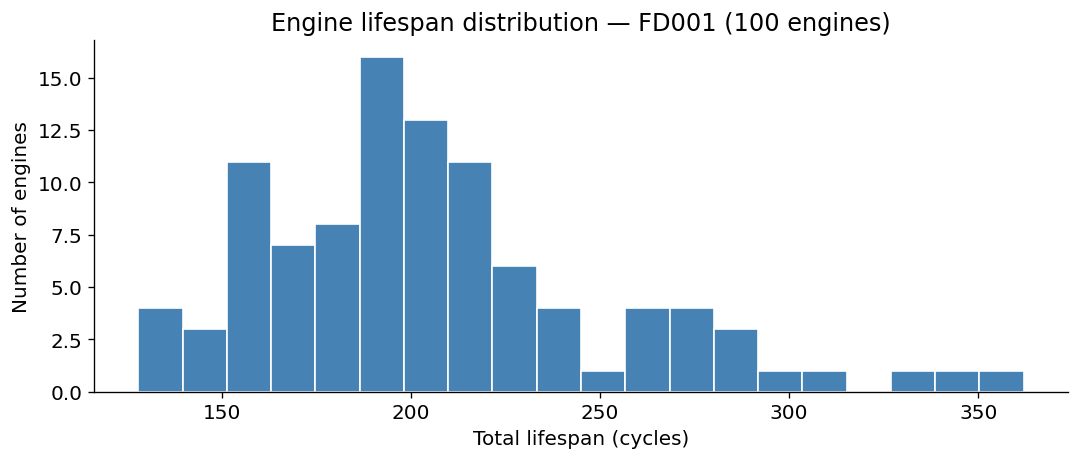

In [57]:
# TODO: plot the engine lifespan histogram
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(engine_lives['max_cycles'],bins=20,color='steelblue',edgecolor='white',lw=0.6)
ax.set_xlabel('Total lifespan (cycles)')
ax.set_ylabel('Number of engines')
ax.set_title('Engine lifespan distribution — FD001 (100 engines)')
plt.tight_layout()
plt.savefig('outputs/engine_lifespans.png', bbox_inches='tight')
plt.show()

---
## ✏️ Exercise 6 / 8 — Degradation signal: Sensor 11

**Why sensor 11?**
In FD001, degradation comes from the HPC *(High-Pressure Compressor)*.
When the HPC loses efficiency → the closed-loop controller increases fuel flow to compensate → **Ps30 rises**.

**Sensor 11 = Ps30** = static pressure at the HPC outlet (psia).
It shows a **monotonic, steady rise** throughout the engine's life — the clearest signal of degradation.

> 📖 Source: Table 2, Saxena et al. (2008), *Damage Propagation Modeling for Aircraft Engine
> Run-to-Failure Simulation*, PHM'08. Values ~47–48 are in **psia** (pressure, not temperature).

To loop over engines and plot one line per engine:
```python
for eng in sample_engines:
    sub = train_df[train_df['unit_number'] == eng]
    ax.plot(sub['time_in_cycles'], sub['sensor_11'], alpha=0.75, label=f'Engine {eng}')
```

---

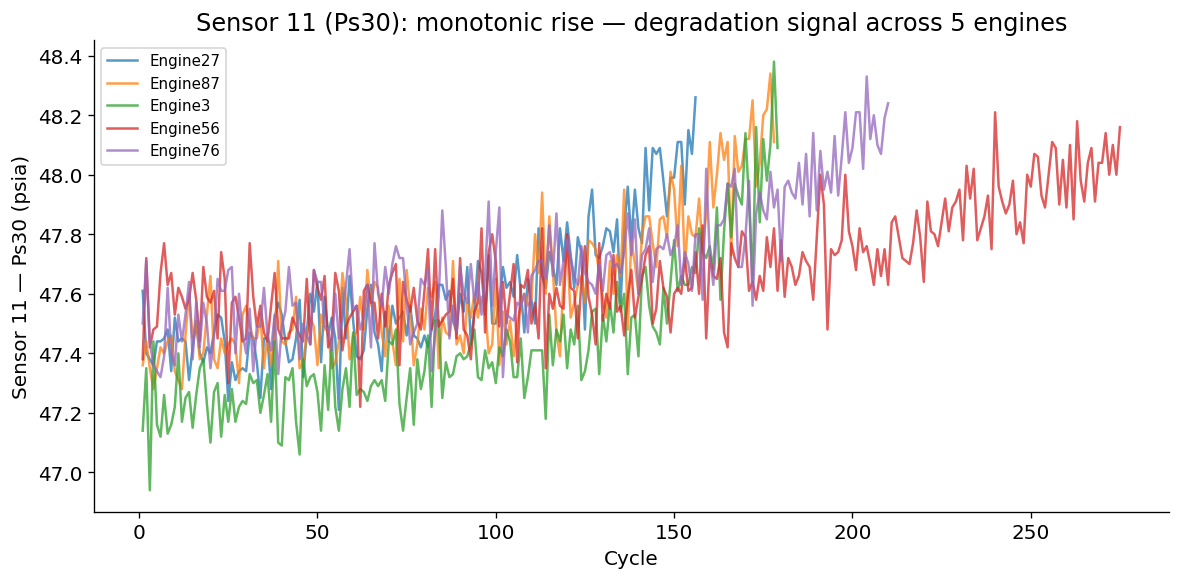

In [62]:
np.random.seed(0)
sample_engines = np.random.choice(train_df['unit_number'].unique(), size=5, replace=False)

fig, ax = plt.subplots(figsize=(10, 5))

# TODO: plot sensor_11 for each engine in sample_engines
for eng in sample_engines:
  sub=train_df[train_df['unit_number']==eng]
  ax.plot(sub['time_in_cycles'],sub['sensor_11'],alpha=0.75,label=f'Engine{eng}')
ax.set_xlabel('Cycle')
ax.set_ylabel('Sensor 11 — Ps30 (psia)')
ax.set_title('Sensor 11 (Ps30): monotonic rise — degradation signal across 5 engines')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('outputs/sensor11_trajectory.png', bbox_inches='tight')
plt.show()

### All 21 sensors — provided cell, observe and compare

> Red = variance < 0.01 (near-constant) · Green = informative
>
> ⚠️ Sensors 08, 13, 15: slight visible variation but variance < 0.01 → the literature drops them anyway.

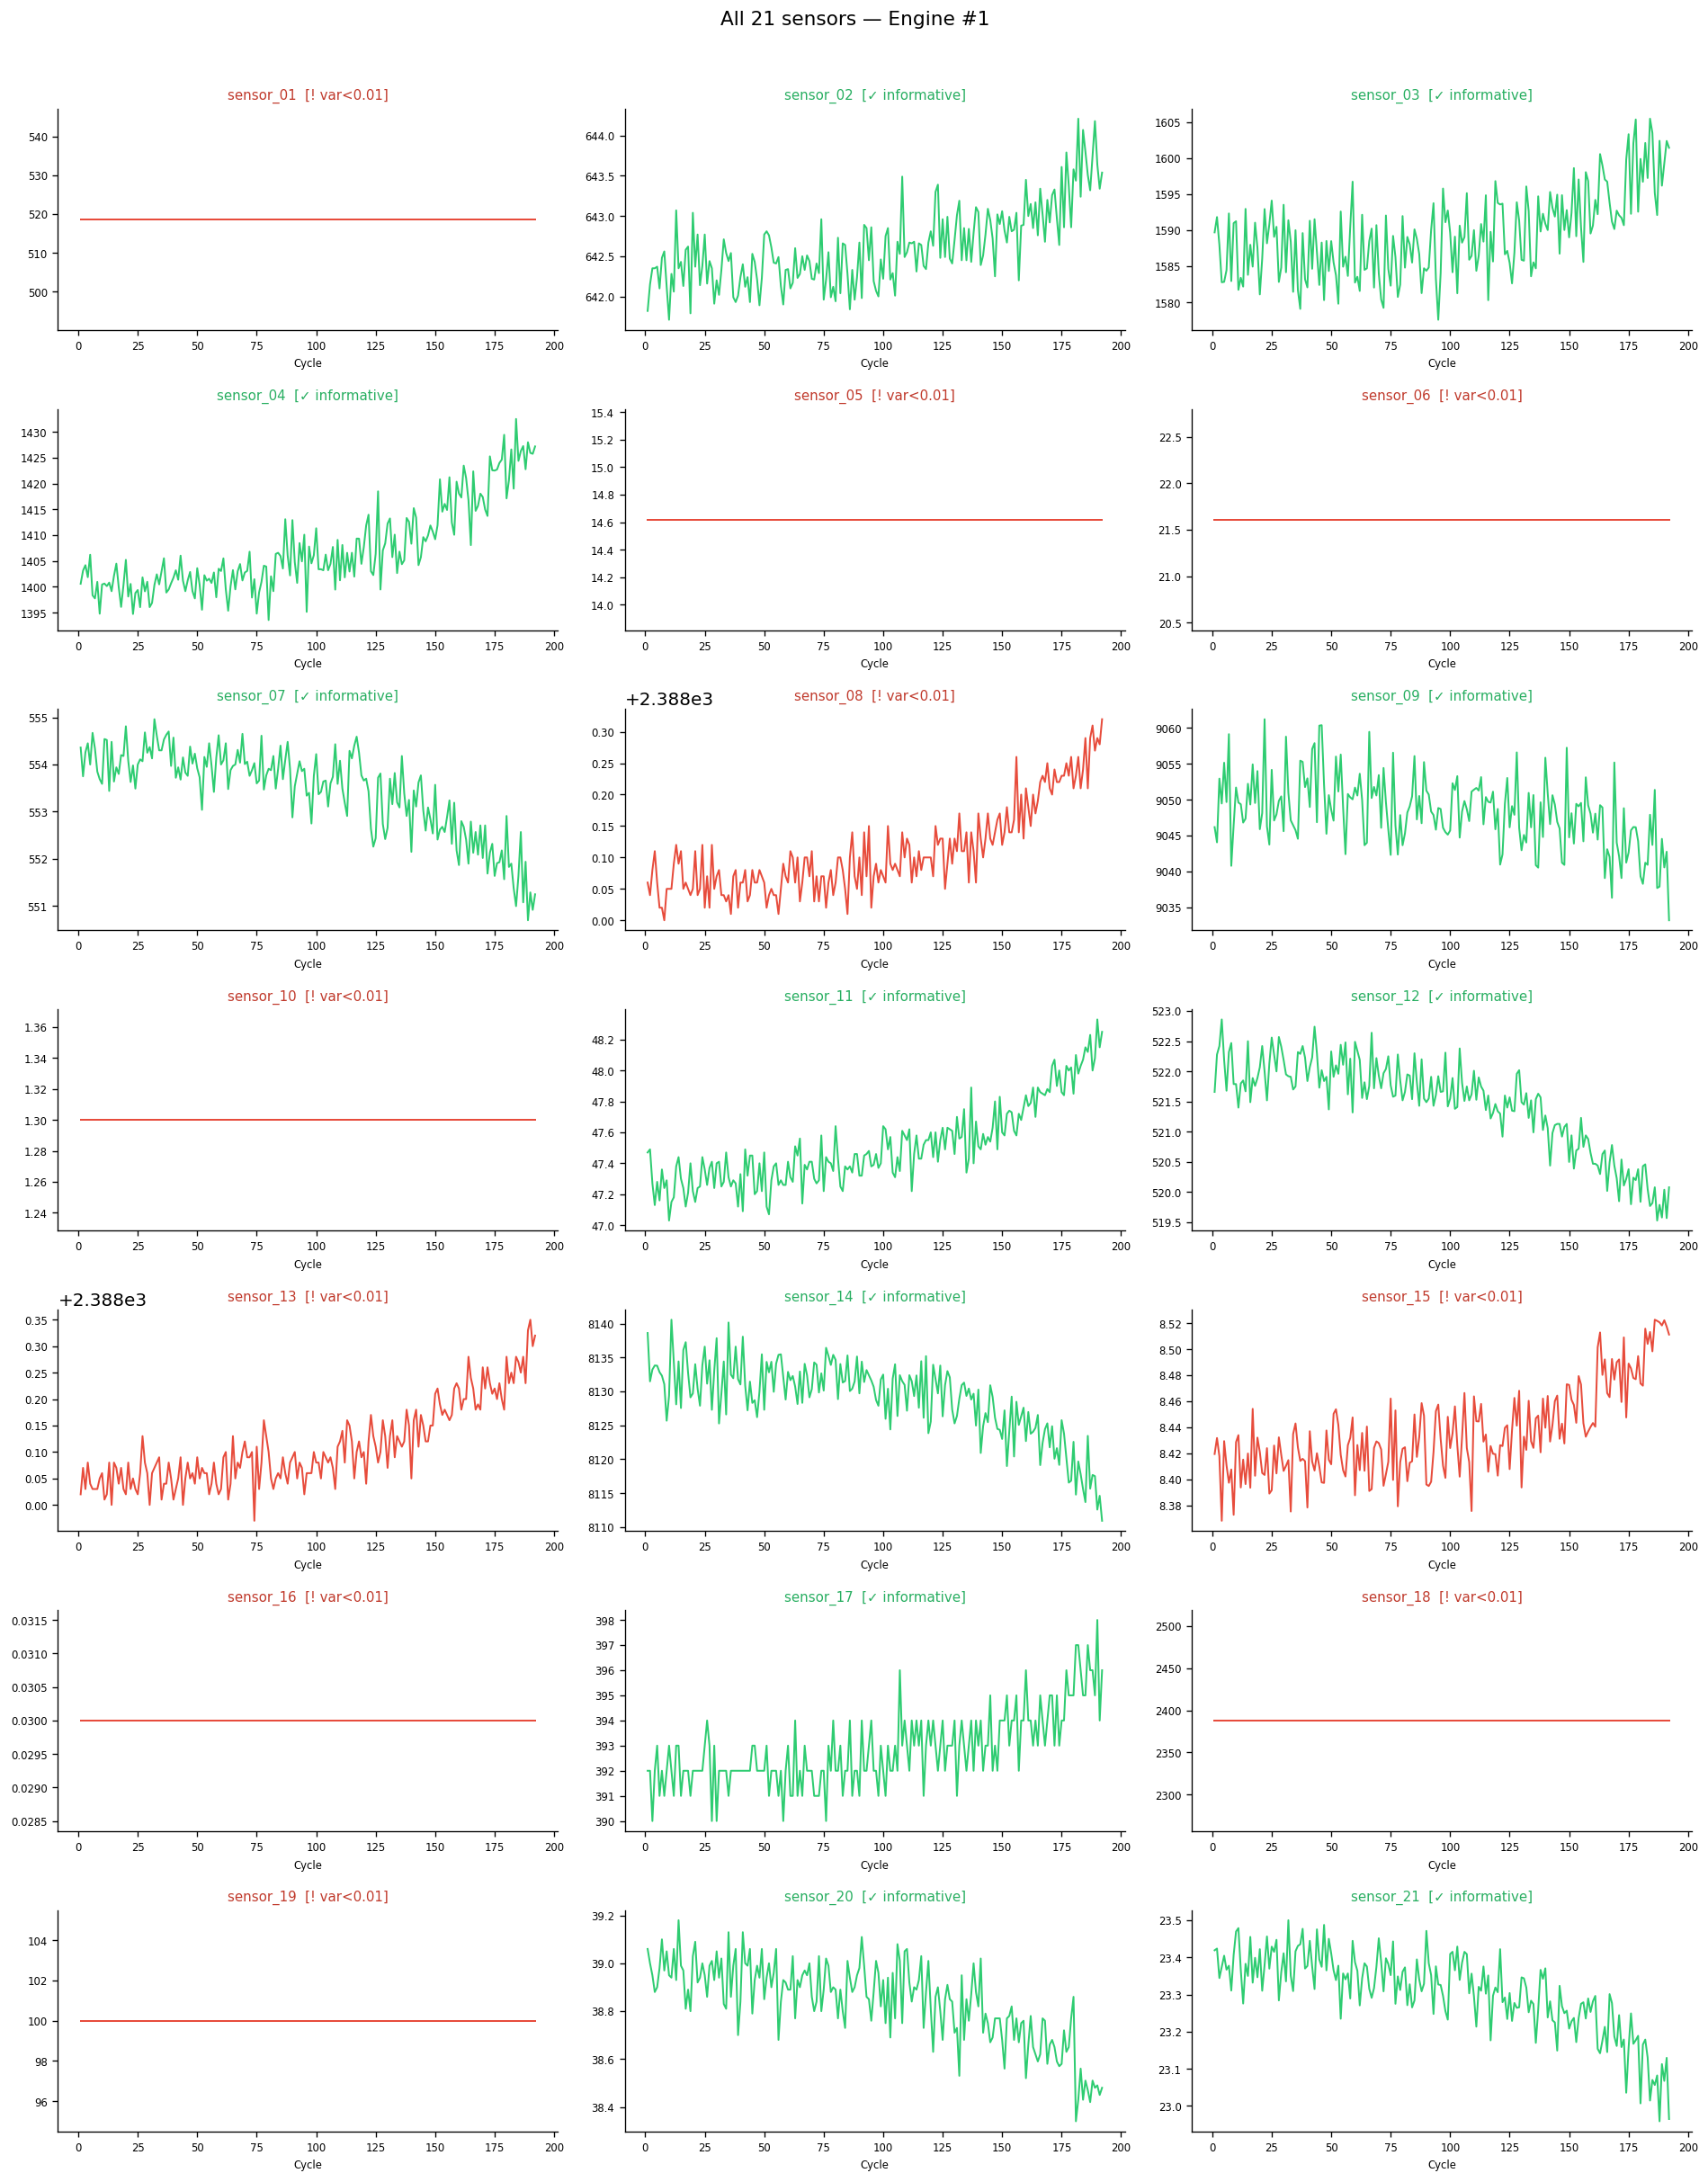

Sensors to drop: ['sensor_01', 'sensor_05', 'sensor_06', 'sensor_08', 'sensor_10', 'sensor_13', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19']


In [63]:
# Provided cell — run and observe
sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]
engine1 = train_df[train_df['unit_number'] == 1].copy()
sensor_var = train_df[sensor_cols].var()
VAR_THRESH = 0.01

fig, axes = plt.subplots(7, 3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    ax = axes[i]
    low = sensor_var[col] < VAR_THRESH
    clr = '#e74c3c' if low else '#2ecc71'
    lbl = '! var<0.01' if low else '✓ informative'
    ax.plot(engine1['time_in_cycles'], engine1[col], color=clr, lw=1.2)
    ax.set_title(f'{col}  [{lbl}]', fontsize=9,
                 color='#c0392b' if low else '#27ae60')
    ax.set_xlabel('Cycle', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(len(sensor_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('All 21 sensors — Engine #1', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/all_sensors_engine1.png', bbox_inches='tight')
plt.show()

dropped = sensor_var[sensor_var < VAR_THRESH].index.tolist()
print(f"Sensors to drop: {dropped}")

### Raw vs normalised variance — provided cell

> Comparing variances on different scales is misleading.
> Example: sensor_08 has values ~2388 → its raw variance looks small even if it varies.
> We normalise first (MinMax 0–1) for a fair comparison.

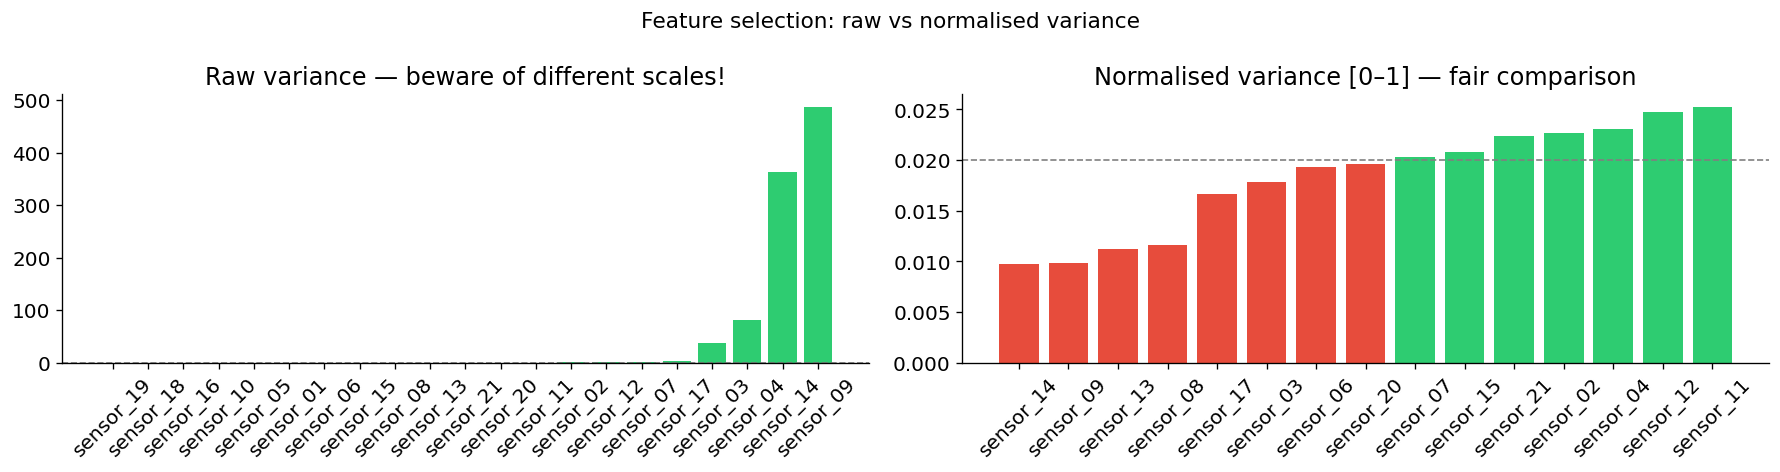

In [64]:
from sklearn.preprocessing import MinMaxScaler

sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]
var_raw = train_df[sensor_cols].var().sort_values()

sensor_range = train_df[sensor_cols].max() - train_df[sensor_cols].min()
non_const = sensor_range[sensor_range > 1e-9].index.tolist()
var_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(train_df[non_const]), columns=non_const
).var().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

c_raw = ['#e74c3c' if v < 0.01 else '#2ecc71' for v in var_raw.values]
axes[0].bar(var_raw.index, var_raw.values, color=c_raw)
axes[0].set_title('Raw variance — beware of different scales!')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(0.01, ls='--', color='gray', lw=1)

c_norm = ['#e74c3c' if v < 0.02 else '#2ecc71' for v in var_norm.values]
axes[1].bar(var_norm.index, var_norm.values, color=c_norm)
axes[1].set_title('Normalised variance [0–1] — fair comparison')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(0.02, ls='--', color='gray', lw=1)

plt.suptitle('Feature selection: raw vs normalised variance', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/sensor_variance.png', bbox_inches='tight')
plt.show()

---
## ✏️ Exercise 7 / 8 — Build the RUL target

The training file has no RUL column — we compute it ourselves.

**Formula:**
```
RUL_raw = engine_max_cycles − current_cycle
```

**Steps:**
1. Find each engine's max cycle with `.groupby().max()` → this is the failure cycle
2. Merge with `train_df` via `.merge(engine_lives, on='unit_number')`
3. Compute `RUL_raw = max_cycles - time_in_cycles`
4. **Clip at 125**: `train_df['RUL_raw'].clip(upper=125)` → stabilises model training
   (a healthy engine gets RUL = 125, not 300 — no need to distinguish)

> 📖 Clip at 125 is a community convention popularised by Heimes (2008). Not in the NASA README.

---

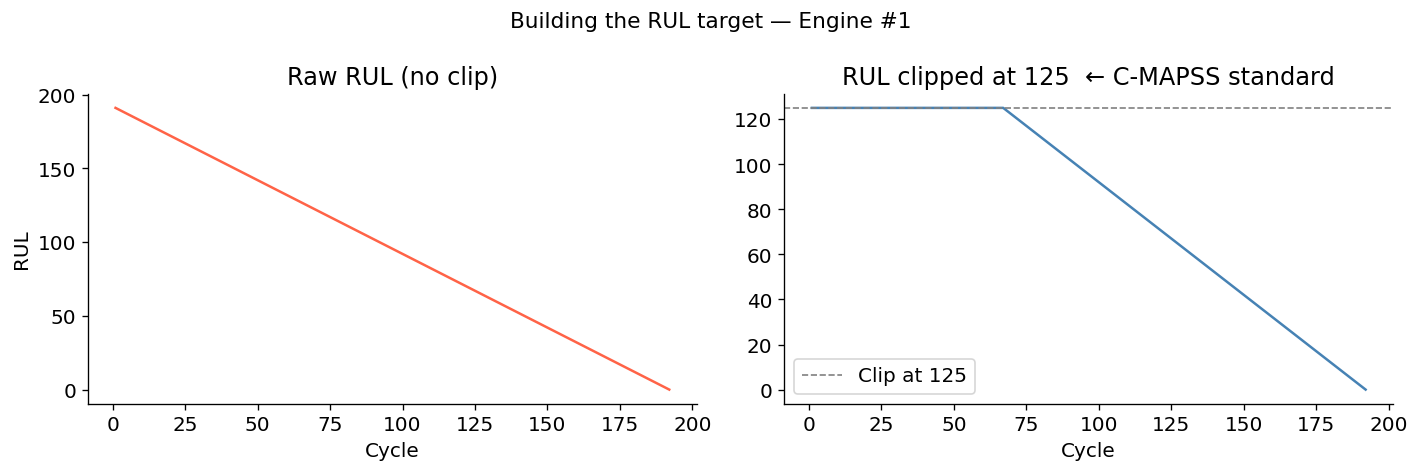

In [67]:
# TODO: compute max_cycles per engine and merge with train_df
engine_lives = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
engine_lives.rename(columns={'time_in_cycles': 'max_cycles'}, inplace=True)
train_df = train_df.merge(engine_lives, on='unit_number')


# TODO: compute RUL_raw
train_df['RUL_raw'] = train_df['max_cycles'] - train_df['time_in_cycles']


# TODO: compute RUL = RUL_raw clipped at 125
train_df['RUL'] = train_df['RUL_raw'].clip(upper=125)


# Visualisation — do not modify
sub = train_df[train_df['unit_number'] == 1]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sub['time_in_cycles'], sub['RUL_raw'], color='tomato')
axes[0].set_title('Raw RUL (no clip)')
axes[0].set_xlabel('Cycle'); axes[0].set_ylabel('RUL')

axes[1].plot(sub['time_in_cycles'], sub['RUL'], color='steelblue')
axes[1].axhline(125, ls='--', color='gray', lw=1, label='Clip at 125')
axes[1].set_title('RUL clipped at 125  ← C-MAPSS standard')
axes[1].set_xlabel('Cycle'); axes[1].legend()

plt.suptitle('Building the RUL target — Engine #1', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/rul_construction.png', bbox_inches='tight')
plt.show()

---
## ✏️ Exercise 8 / 8 — Engine-level split (leak-free)

We have 100 engines → 80 train / 10 val / 10 test.

**Why not use `train_test_split`?**
Because it splits **rows**, not **engines**.
Result: cycles 1–100 of an engine would be in train, and cycles 101–200 of the *same* engine in val.
The model would already "know" that engine → **data leakage**.

**Correct method:**
1. `np.random.shuffle(all_engines)` → shuffle the 100 engine IDs
2. Slice: `all_engines[:80]`, `all_engines[80:90]`, `all_engines[90:]`
3. Filter with `.isin()`
4. **Assert** that the sets do not overlap

---

In [69]:
np.random.seed(42)
all_engines = train_df['unit_number'].unique()
np.random.shuffle(all_engines)

# TODO: create train_engines (first 80), val_engines (next 10), test_engines (last 10)
train_engines = all_engines[:80]
val_engines   = all_engines[80:90]
test_engines  = all_engines[90:]


# TODO: filter train_df to get df_train, df_val, df_test
df_train = train_df[train_df['unit_number'].isin(train_engines)]
df_val   = train_df[train_df['unit_number'].isin(val_engines)]
df_test  = train_df[train_df['unit_number'].isin(test_engines)]


# Display — do not modify
print(f"Train: {len(train_engines)} engines — {len(df_train):,} rows")
print(f"Val:   {len(val_engines)} engines — {len(df_val):,} rows")
print(f"Test:  {len(test_engines)} engines — {len(df_test):,} rows")

# TODO: write the two assertions to verify there is no leakage
assert len(set(train_engines) & set(val_engines)) == 0, "Leakage between Train and Val!"
assert len(set(train_engines) & set(test_engines)) == 0, "Leakage between Train and Test!"
print("\n✓ No leakage — every engine is in exactly one set.")

Train: 80 engines — 16,340 rows
Val:   10 engines — 2,082 rows
Test:  10 engines — 2,209 rows

✓ No leakage — every engine is in exactly one set.


### Save — provided cell

In [70]:
os.makedirs('data/processed', exist_ok=True)

exclude = ['unit_number', 'time_in_cycles', 'max_cycles', 'RUL_raw']
feature_cols = [c for c in df_train.columns if c not in exclude]

df_train[feature_cols + ['RUL']].to_csv('data/processed/train.csv', index=False)
df_val  [feature_cols + ['RUL']].to_csv('data/processed/val.csv',   index=False)
df_test [feature_cols + ['RUL']].to_csv('data/processed/test.csv',  index=False)
print(f"✓ {len(feature_cols)} features saved → data/processed/")

✓ 25 features saved → data/processed/


---
## 9 · Key takeaways

- **`.shape`, `.head()`, `.tail()`, `.info()`, `.isnull()`, `.describe()`** → the 6 basic reflexes on any new dataset
- Sensors with variance < 0.01 in FD001 are constant because there is only one operating condition
- **Sensor 11 = Ps30** shows a monotonic rise → clearest visible degradation signal
  *(Source: Saxena et al. 2008, Table 2)*
- RUL clipped at 125 refocuses training on the degradation phase
- Splitting by `unit_number` is **mandatory** to avoid data leakage

## 10 · Before next session ✅

| # | Task | Done? |
|---|------|:-----:|
| 1 | Run this notebook end-to-end without errors | ☐ |
| 2 | Confirm `data/processed/train.csv`, `val.csv`, `test.csv` exist | ☐ |
| 3 | Open `train_FD001.txt` in a text editor — observe the raw columns | ☐ |
| 4 | Answer: why is sensor_01 useless and sensor_11 (Ps30) useful? | ☐ |
| 5 | Answer: what happens if we don't clip the RUL? | ☐ |
| 6 | Answer: what is data leakage and how do we avoid it here? | ☐ |
| 7 | (Bonus) Repeat with FD002 — how many constant sensors this time? | ☐ |

---
*Session 2: Temporal windowing → multiple model exploration → NASA asymmetric scoring metric*
*بارك الله فيكم 🤲*